In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

In [6]:
# 1. ĐỌC DỮ LIỆU TỪ FILE CSV
ten_file = "Laptop_PhongVu.csv" 

try:
    df = pd.read_csv(ten_file)
    print(f"Đã tải thành công {len(df)} sản phẩm từ file '{ten_file}'")
except FileNotFoundError:
    print(f"Không tìm thấy file '{ten_file}'. Hãy chạy code thu thập dữ liệu trước nhé!")
    exit()

# 2. LÀM SẠCH VÀ CHUẨN BỊ DỮ LIỆU
def lam_sach_gia(gia_text):
    if pd.isna(gia_text) or str(gia_text).strip() == "Liên hệ": return 0
    gia_clean = re.sub(r"[^\d]", "", str(gia_text))
    return int(gia_clean) if gia_clean else 0

def lay_thuong_hieu(ten_sp):
    tu_khoa = str(ten_sp).upper().split()
    if not tu_khoa: return "UNKNOWN"
    if tu_khoa[0] == "LAPTOP" and len(tu_khoa) > 1: return tu_khoa[1]
    if "MACBOOK" in tu_khoa[0]: return "APPLE"
    return tu_khoa[0]

# Xử lý 2 cột giá mới
df["Giá gốc (VNĐ)"] = df["Giá gốc"].apply(lam_sach_gia)
df["Giá hiện tại (VNĐ)"] = df["Giá hiện tại"].apply(lam_sach_gia)

# Lọc các máy hợp lệ
df_hop_le = df[df["Giá hiện tại (VNĐ)"] > 0].copy()

if df_hop_le.empty:
    print("Không có sản phẩm nào có giá hợp lệ.")
    exit()

# Bổ sung các cột thông tin
df_hop_le['Thương hiệu'] = df_hop_le['Tên sản phẩm'].apply(lay_thuong_hieu)
df_hop_le['Tên rút gọn'] = df_hop_le['Tên sản phẩm'].apply(lambda x: str(x)[:45] + '...' if len(str(x)) > 45 else str(x))

# Tính toán mức giảm giá
df_hop_le["Tiền giảm (VNĐ)"] = df_hop_le["Giá gốc (VNĐ)"] - df_hop_le["Giá hiện tại (VNĐ)"]
df_hop_le["% Giảm giá"] = df_hop_le.apply(
    lambda row: (row["Tiền giảm (VNĐ)"] / row["Giá gốc (VNĐ)"]) * 100 if row["Giá gốc (VNĐ)"] > 0 else 0, 
    axis=1
)

Đã tải thành công 10 sản phẩm từ file 'Laptop_PhongVu.csv'


In [7]:
# 3. PHÂN TÍCH VÀ THỐNG KÊ (CONSOLE)
print("\nBÁO CÁO PHÂN TÍCH GIÁ LAPTOP TẠI PHONG VŨ:")

print(f"Tổng số máy có giá công khai: {len(df_hop_le)}/{len(df)} máy")
print(f"Mức giá trung bình: {df_hop_le['Giá hiện tại (VNĐ)'].mean():,.0f} VNĐ")

may_dat_nhat = df_hop_le.loc[df_hop_le["Giá hiện tại (VNĐ)"].idxmax()]
print(f"\nMÁY CAO CẤP NHẤT:\n   - {may_dat_nhat['Tên sản phẩm']} \n   - Giá: {may_dat_nhat['Giá hiện tại (VNĐ)']:,.0f} VNĐ")

may_re_nhat = df_hop_le.loc[df_hop_le["Giá hiện tại (VNĐ)"].idxmin()]
print(f"\nMÁY PHỔ THÔNG NHẤT:\n   - {may_re_nhat['Tên sản phẩm']} \n   - Giá: {may_re_nhat['Giá hiện tại (VNĐ)']:,.0f} VNĐ")

# Phân tích Khuyến mãi
df_khuyen_mai = df_hop_le[df_hop_le["Tiền giảm (VNĐ)"] > 0]
if not df_khuyen_mai.empty:
    best_deal = df_khuyen_mai.loc[df_khuyen_mai["% Giảm giá"].idxmax()]
    print(f"\nDEAL SALE SỐC NHẤT HIỆN TẠI:")
    print(f"   - Tên máy: {best_deal['Tên sản phẩm']}")
    print(f"   - Đang bán: {best_deal['Giá hiện tại (VNĐ)']:,.0f} VNĐ (Gốc: {best_deal['Giá gốc (VNĐ)']:,.0f} VNĐ)")
    print(f"   - Mức giảm: {best_deal['% Giảm giá']:.1f}% (-{best_deal['Tiền giảm (VNĐ)']:,.0f} VNĐ)")


BÁO CÁO PHÂN TÍCH GIÁ LAPTOP TẠI PHONG VŨ:
Tổng số máy có giá công khai: 10/10 máy
Mức giá trung bình: 27,371,000 VNĐ

MÁY CAO CẤP NHẤT:
   - Laptop Lenovo Ideapad Slim 5 14AGP11 - 83S1003GVN (Ryzen AI 7 445/ 32GB/ 1TB/ Windows 11 Home SL) 
   - Giá: 42,990,000 VNĐ

MÁY PHỔ THÔNG NHẤT:
   - Laptop HP 15-fc0024AU - D0BH2PA (Ryzen 5 7520U/ 16GB/ 512GB/ Windows 11 Home) 
   - Giá: 16,490,000 VNĐ

DEAL SALE SỐC NHẤT HIỆN TẠI:
   - Tên máy: Laptop Msi Katana B14WEK-286VN (i5-14450HX/ GeForce RTX™ 5050/ 16GB/ 512GB/ Win 11 Home)
   - Đang bán: 33,190,000 VNĐ (Gốc: 41,990,000 VNĐ)
   - Mức giảm: 21.0% (-8,800,000 VNĐ)


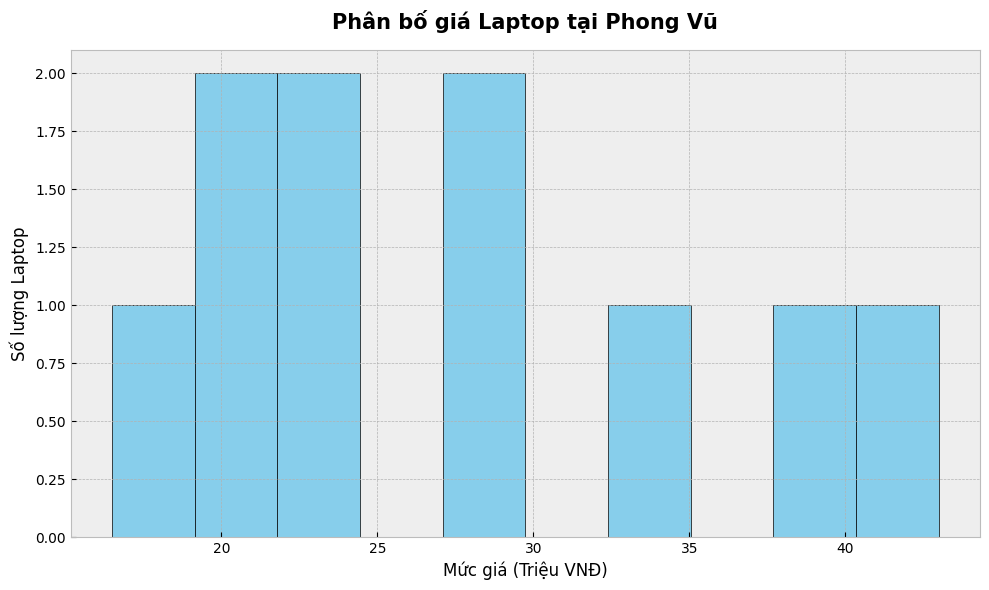

In [10]:
# 4. TRỰC QUAN HÓA DỮ LIỆU (MATPLOTLIB)
plt.style.use('bmh')

# --- BIỂU ĐỒ 1: PHÂN BỐ GIÁ TỔNG QUAN ---
plt.figure(figsize=(10, 6))
plt.hist(df_hop_le['Giá hiện tại (VNĐ)'] / 1000000, bins=10, color='skyblue', edgecolor='black')
plt.title('Phân bố giá Laptop tại Phong Vũ', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Mức giá (Triệu VNĐ)', fontsize=12)
plt.ylabel('Số lượng Laptop', fontsize=12)
plt.tight_layout()
plt.show()

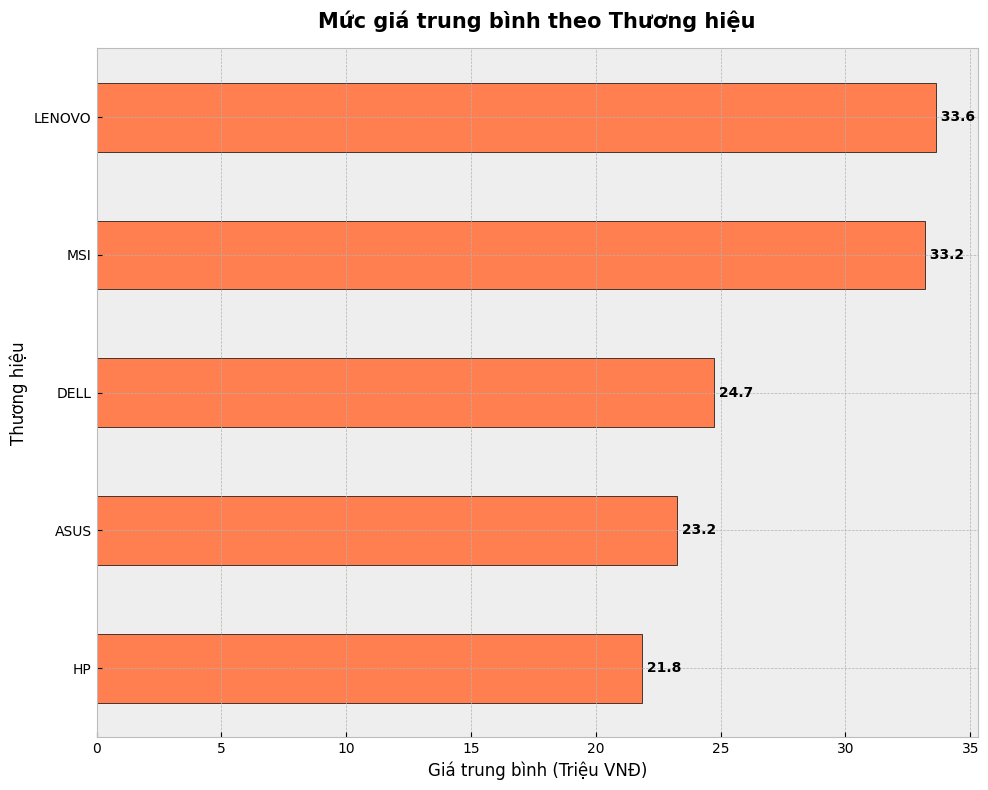

In [11]:
# --- BIỂU ĐỒ 2: GIÁ TRUNG BÌNH THEO THƯƠNG HIỆU ---
gia_tb_hang = df_hop_le.groupby('Thương hiệu')['Giá hiện tại (VNĐ)'].mean().sort_values(ascending=True) / 1000000
plt.figure(figsize=(10, 8))
gia_tb_hang.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Mức giá trung bình theo Thương hiệu', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Giá trung bình (Triệu VNĐ)', fontsize=12) 
for index, value in enumerate(gia_tb_hang):
    plt.text(value, index, f" {value:,.1f}", va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

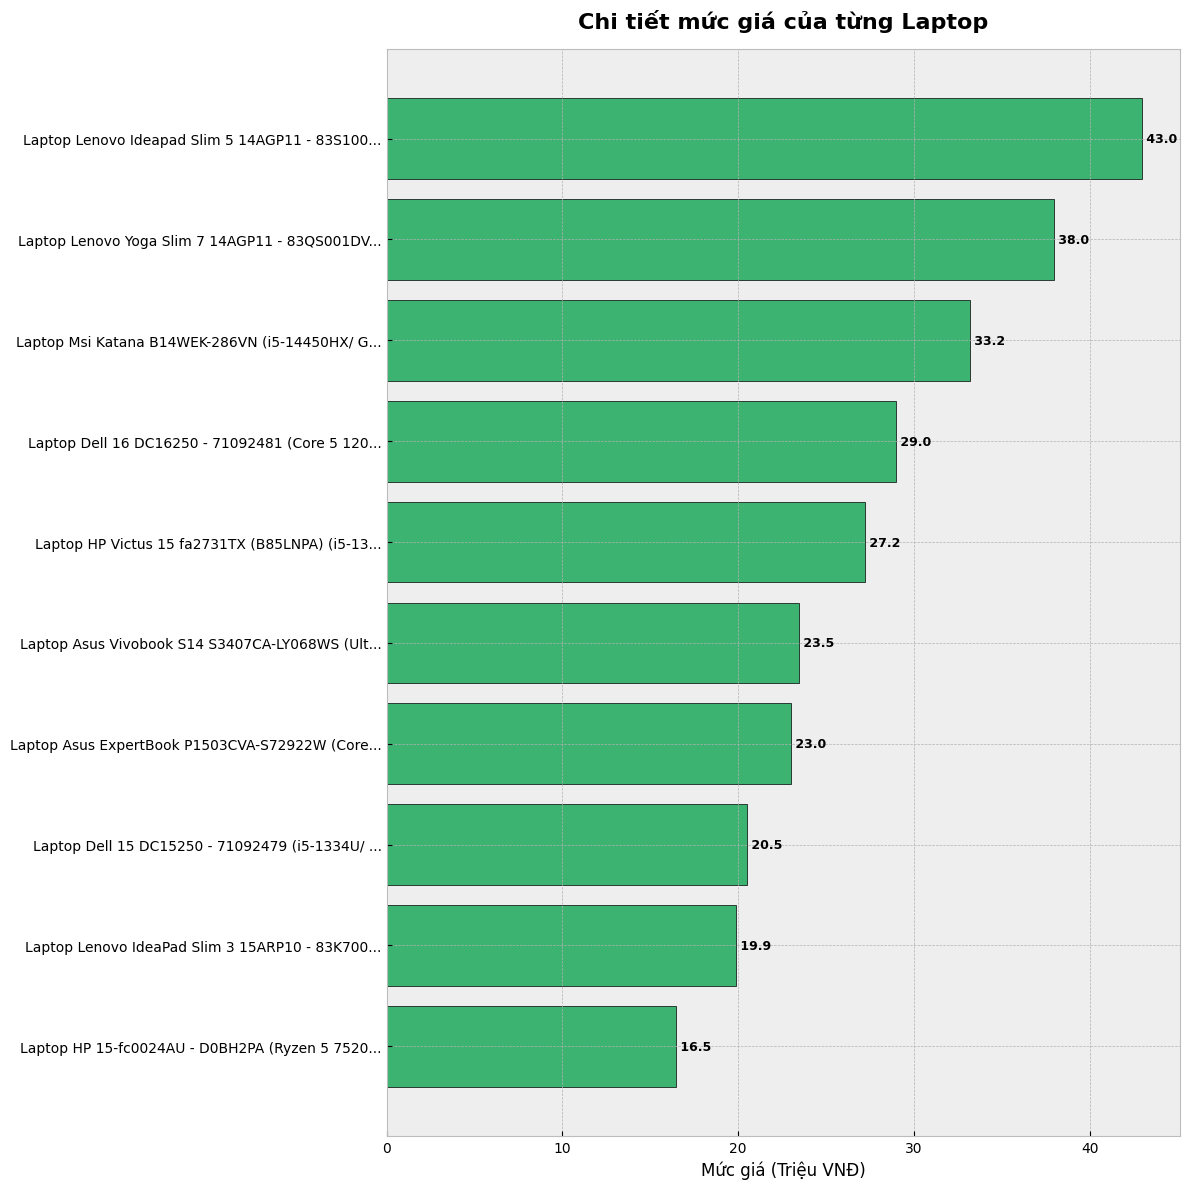

In [12]:
# --- BIỂU ĐỒ 3: CHI TIẾT MỨC GIÁ CỦA TỪNG SẢN PHẨM ---
df_sorted = df_hop_le.sort_values(by='Giá hiện tại (VNĐ)', ascending=True)
plt.figure(figsize=(12, 12)) 
plt.barh(df_sorted['Tên rút gọn'], df_sorted['Giá hiện tại (VNĐ)'] / 1000000, color='mediumseagreen', edgecolor='black')
plt.title('Chi tiết mức giá của từng Laptop', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Mức giá (Triệu VNĐ)', fontsize=12)
for index, value in enumerate(df_sorted['Giá hiện tại (VNĐ)'] / 1000000):
    plt.text(value, index, f" {value:,.1f}", va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

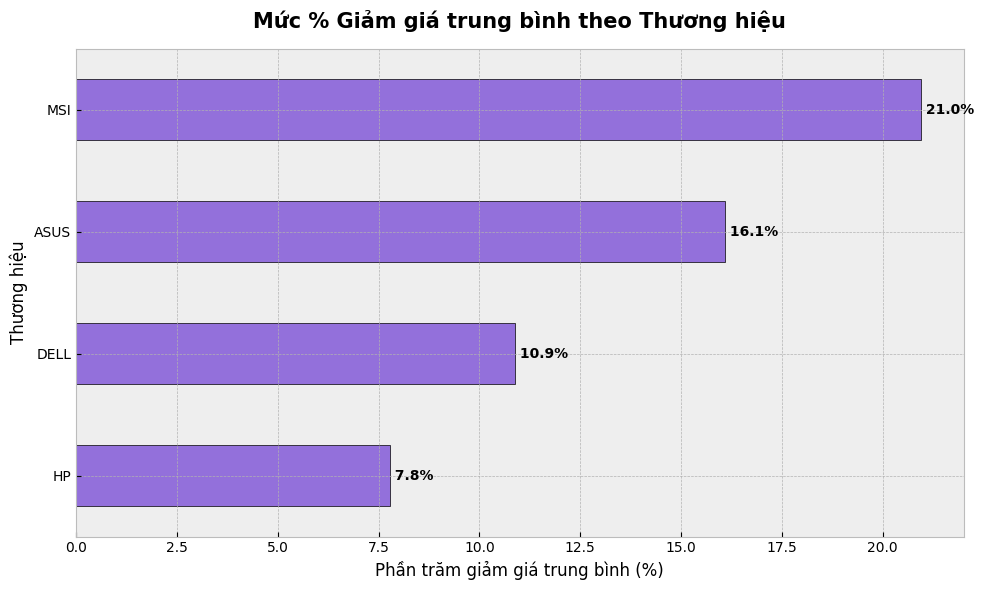

In [13]:
# --- BIỂU ĐỒ 4: HÃNG NÀO HAY KHUYẾN MÃI NHẤT? ---
if not df_khuyen_mai.empty:
    giam_gia_tb_hang = df_khuyen_mai.groupby("Thương hiệu")["% Giảm giá"].mean().sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    giam_gia_tb_hang.plot(kind='barh', color='mediumpurple', edgecolor='black')
    plt.title('Mức % Giảm giá trung bình theo Thương hiệu', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Phần trăm giảm giá trung bình (%)', fontsize=12) 
    for index, value in enumerate(giam_gia_tb_hang):
        plt.text(value, index, f" {value:.1f}%", va='center', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()